# Tesis MIA — Parte 1: Generador del Sistema Económico (ARIMA(1,1,1) + GARCH(1,1))
**Mauricio Riquelme Alvarado · MIA-PUC · Prof. Marcelo Mendoza**

Reproduce en Python/Colab la **memoria de cálculo de Mathcad "Parte 1 — Time Series"**: un laboratorio econométrico que sintetiza las tres series chilenas (Cobre, USD/CLP, TPM) combinando **GARCH(1,1)** (volatilidad condicional), un **enlace causal** vía el grafo de dominio $G$, y un **integrador ARIMA(1,1,1)** (nivel y persistencia). Incluye los gráficos, las pruebas de verificación (estacionariedad, dimensiones, correlaciones con tolerancia) y los textos explicativos de la memoria original.

> La ventana de ejemplo `xe` $\in\mathbb{R}^{3\times15}$ que produce este cuaderno es exactamente la entrada $X$ de la Fase 1 (Tokenización) de la Parte 2A.

## 0. Configuración 🔧

In [1]:
import numpy as np
import matplotlib.pyplot as plt
SEED = 35                     # reproduce los valores de correlación de la memoria Mathcad
print("NumPy", np.__version__)

NumPy 2.4.4


## 1. Fundamento: descomposición estructural ARIMA + GARCH 📖
En econometría financiera una serie se descompone en **nivel** e **innovaciones**:
$$y_t = \underbrace{\mathrm{ARIMA}(\mu_t)}_{\text{tendencia y persistencia}} + \underbrace{\varepsilon_t}_{\text{GARCH: volatilidad variable}}$$
- **GARCH(1,1)** modela la *heterocedasticidad condicional* (clusters de volatilidad): períodos de alta y baja incertidumbre.
- **ARIMA(1,1,1)** modela la *estructura de dependencia temporal del valor esperado* (memoria, reversión a la media, deriva).

Entrenar el Transformer con ambas capas lo obliga a aprender simultáneamente la **dinámica del nivel** y los **patrones de volatilidad**, generando series sintéticas mucho más realistas para el caso chileno.

## 2. Parámetros de las tres series 📐
Cada serie tiene parámetros **GARCH** $(\omega,\alpha,\beta)$ y **ARIMA** $(\phi,\theta,S_0)$. La calibración respeta una **jerarquía de volatilidad** $\omega_{Cu}>\omega_{USD}>\omega_{TPM}$ y la **condición de estacionariedad** $\alpha+\beta<1$ en todas.

- **Cobre** — *motor de shocks*: $\omega$ y $\alpha$ altos; commodity global, volatilidad estructural intrínsecamente superior.
- **USD/CLP** — *volatilidad media*: depende de los shocks del cobre, pero su GARCH amortigua los cambios bruscos.
- **TPM** — *proceso suave/inercial*: $\beta=0.90$ (alta persistencia); la política monetaria cambia lento.

In [2]:
T, p, q, d = 1000, 1, 1, 1
# GARCH (ω, α, β) por serie
PCu  = (0.04, 0.05, 0.30)    # Cobre   — motor de shocks
PUSD = (0.03, 0.03, 0.05)    # USD/CLP — volatilidad media
PTPM = (0.01, 0.01, 0.90)    # TPM     — suave / inercial
# ARIMA (φ, θ, S0) por serie
PHI, THETA, S0 = [0.5, 0.2, 0.1], [0.05, 0.05, 0.05], [100, 100, 100]
NAMES = ["Cu", "USD/CLP", "TPM"]

print("serie     ω     α     β    α+β   estacionario   |  φ     θ    S0")
for nm,(w,a,b),ph,th,s in zip(NAMES,[PCu,PUSD,PTPM],PHI,THETA,S0):
    print(f"{nm:8s} {w:.2f}  {a:.2f}  {b:.2f}  {a+b:.2f}   {'✓ (<1)' if a+b<1 else '✗':7s}      | {ph:.1f}  {th:.2f}  {s}")
print(f"\nJerarquía de volatilidad ω_Cu>ω_USD>ω_TPM: {PCu[0]}>{PUSD[0]}>{PTPM[0]}  ->  {PCu[0]>PUSD[0]>PTPM[0]} ✓")

serie     ω     α     β    α+β   estacionario   |  φ     θ    S0
Cu       0.04  0.05  0.30  0.35   ✓ (<1)       | 0.5  0.05  100
USD/CLP  0.03  0.03  0.05  0.08   ✓ (<1)       | 0.2  0.05  100
TPM      0.01  0.01  0.90  0.91   ✓ (<1)       | 0.1  0.05  100

Jerarquía de volatilidad ω_Cu>ω_USD>ω_TPM: 0.04>0.03>0.01  ->  True ✓


## 3. El grafo causal de dominio $G$ 🧭
$G$ codifica la cadena macro-financiera chilena con coeficientes de acoplamiento entre las **innovaciones**:

$$G=\begin{pmatrix}1&0&0\\-0.6&1&0\\0.4&-0.2&1\end{pmatrix}$$

- $\rho_{Cu\to USD}=-0.6$: Cobre $\uparrow$ → Chile exporta más → CLP se aprecia → **USD/CLP $\downarrow$**.
- $\rho_{Cu\to TPM}=+0.4$: Cobre $\uparrow$ → ingresos fiscales $\uparrow$ → inversión $\uparrow$ → **TPM $\uparrow$**.
- $\rho_{USD\to TPM}=-0.2$: USD/CLP $\uparrow$ (peso débil) → importaciones $\uparrow$ → **TPM $\downarrow$**.

**¿Por qué TPM y no PIB?** El PIB chileno es *trimestral*, con rezago de 45–60 días y revisiones posteriores → introduce señal artificial e información no disponible al momento de predecir. La **TPM** es *mensual*, sin revisiones, se publica el día que se decide, y tiene causalidad **operacional** directa con el tipo de cambio (el Banco Central sube la TPM para defender el peso).

In [3]:
G = np.array([[ 1.0,  0.0, 0.0],
              [-0.6,  1.0, 0.0],
              [ 0.4, -0.2, 1.0]])
print("G =\n", G)

G =
 [[ 1.   0.   0. ]
 [-0.6  1.   0. ]
 [ 0.4 -0.2  1. ]]


## 4. Funciones del generador ⚙️  *(fieles a la memoria Mathcad)*
`GenerateCorrelatedShocks` → `Causal_Link` → `SimulateGARCH` (×3) → `IntegradorARIMA` (×3), orquestadas por `Generar_Sistema_Economico`.

In [4]:
def SimulateGARCH(T, omega, alpha, beta, z):
    """GARCH(1,1): h_0 = ω/(1-α-β); h_t = ω + α·ε²_{t-1} + β·h_{t-1}; ε_t = z_t·√h_t."""
    h = np.zeros(T); e = np.zeros(T)
    h[0] = omega/(1 - alpha - beta)              # varianza incondicional
    e[0] = z[0]*np.sqrt(h[0])
    for t in range(1, T):
        h[t] = omega + alpha*e[t-1]**2 + beta*h[t-1]
        e[t] = z[t]*np.sqrt(h[t])
    return e, h

def IntegradorARIMA(eps, phi, theta, S0, T):
    """ARIMA(1,1,1): dx_t = φ·dx_{t-1} + θ·ε_{t-1} + ε_t ; S_t = S_{t-1} + dx_t (integración I(1))."""
    S = np.zeros(T); dx = np.zeros(T); S[0] = S0
    for t in range(1, T):
        dx[t] = phi*dx[t-1] + theta*eps[t-1] + eps[t]
        S[t]  = S[t-1] + dx[t]
    return S

def GenerateCorrelatedShocks(T, rng):
    """Tres columnas de ruido blanco N(0,1) independientes -> Zbase [T×3]."""
    return np.stack([rng.normal(0,1,T), rng.normal(0,1,T), rng.normal(0,1,T)], 1)

def Causal_Link(Zb, G):
    """Mezcla lineal de los shocks vía G: inyecta la estructura causal Cu→USD/CLP→TPM."""
    zCu, zUSD, zPGD = Zb[:,0], Zb[:,1], Zb[:,2]
    return np.stack([zCu,
                     zUSD + G[1,0]*zCu,                    # USD recibe shock del cobre
                     zPGD + G[2,0]*zCu + G[2,1]*zUSD], 1)  # TPM recibe cobre y USD

def Normalizar(S):
    """Indexa la serie a base 100 (S_0 = 100)."""
    return S/S[0]*100.0

def Generar_Sistema_Economico(T, G, PCu, PUSD, PTPM, Zbase):
    Zc = Causal_Link(Zbase, G)                                   # innovaciones correlacionadas
    eCu , _ = SimulateGARCH(T, *PCu , Zc[:,0])                   # ETAPA 1: motores GARCH
    eUSD, _ = SimulateGARCH(T, *PUSD, Zc[:,1])
    eTPM, _ = SimulateGARCH(T, *PTPM, Zc[:,2])
    # ETAPA 3: integrador ARIMA por serie (nivel)
    SCU  = IntegradorARIMA(eCu , PHI[0], THETA[0], S0[0], T)
    SUSD = IntegradorARIMA(eUSD, PHI[1], THETA[1], S0[1], T)
    STPM = IntegradorARIMA(eTPM, PHI[2], THETA[2], S0[2], T)
    # salida T×6: [3 niveles | 3 innovaciones causales]
    return np.column_stack([SCU, SUSD, STPM, Zc[:,0], Zc[:,1], Zc[:,2]])
print("Funciones del generador definidas.")

Funciones del generador definidas.


## 5. Ejecutar la simulación 🚀

In [5]:
rng = np.random.default_rng(SEED)
Zbase = GenerateCorrelatedShocks(T, rng)
x = Generar_Sistema_Economico(T, G, PCu, PUSD, PTPM, Zbase)
print("Verificación de dimensiones:")
print(f"  rows(x) = {x.shape[0]}  (esperado 1000)")
print(f"  cols(x) = {x.shape[1]}  (esperado 6 = 3 niveles + 3 innovaciones)")

Verificación de dimensiones:
  rows(x) = 1000  (esperado 1000)
  cols(x) = 6  (esperado 6 = 3 niveles + 3 innovaciones)


## 6. Gráfico de las series 📈
Las tres series de nivel, indexadas a base 100 (`Normalizar`), tal como en la memoria ("ARIMA(1,1,1) + GARCH(1,1) Data Series").

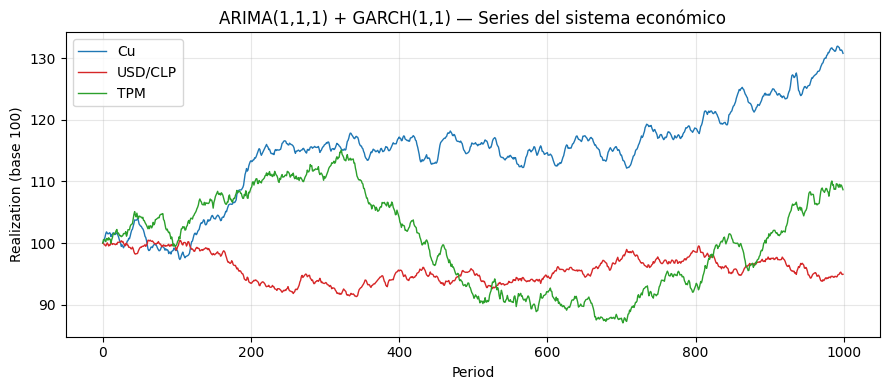

In [6]:
eps_levels = [Normalizar(x[:, i]) for i in range(3)]
plt.figure(figsize=(9, 4))
for s, nm, c in zip(eps_levels, NAMES, ["tab:blue","tab:red","tab:green"]):
    plt.plot(s, label=nm, lw=1.0, color=c)
plt.title("ARIMA(1,1,1) + GARCH(1,1) — Series del sistema económico")
plt.xlabel("Period"); plt.ylabel("Realization (base 100)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 7. Pruebas de verificación ✓
Auditamos la integridad del generador con las mismas pruebas de la memoria: estacionariedad, dimensiones y **correlaciones observadas vs. el grafo $G$** con tolerancia $\varepsilon_{tol}=0.15$.

In [7]:
# (a) Estacionariedad por serie
print("ESTACIONARIEDAD (α+β < 1):")
for nm,(w,a,b) in zip(NAMES,[PCu,PUSD,PTPM]):
    print(f"  {nm:8s} α+β = {a+b:.2f}  ->  {'PASS ✓' if a+b<1 else 'FAIL'}")

# (b) Correlaciones sobre las innovaciones causales (columnas 3-5)
rCu, rUSD, rTPM = x[:,3], x[:,4], x[:,5]
obs = {"Cu ↔ USD":np.corrcoef(rCu,rUSD)[0,1],
       "Cu ↔ TPM":np.corrcoef(rCu,rTPM)[0,1],
       "USD ↔ TPM":np.corrcoef(rUSD,rTPM)[0,1]}
exp = {"Cu ↔ USD":G[1,0], "Cu ↔ TPM":G[2,0], "USD ↔ TPM":G[2,1]}
TOL = 0.15
print(f"\nCORRELACIONES (tolerancia ε_tol = {TOL}):")
print("  par           observada   esperada(G)   error    status")
for k in obs:
    err = abs(obs[k]-exp[k]); st = "PASS ✓" if err < TOL else "FAIL ✗"
    print(f"  {k:11s}   {obs[k]:+.3f}      {exp[k]:+.2f}        {err:.3f}    {st}")

print(f"\nDIMENSIONES: rows={x.shape[0]} ✓  cols={x.shape[1]} ✓")

ESTACIONARIEDAD (α+β < 1):
  Cu       α+β = 0.35  ->  PASS ✓
  USD/CLP  α+β = 0.08  ->  PASS ✓
  TPM      α+β = 0.91  ->  PASS ✓

CORRELACIONES (tolerancia ε_tol = 0.15):
  par           observada   esperada(G)   error    status
  Cu ↔ USD      -0.508      -0.60        0.092    PASS ✓
  Cu ↔ TPM      +0.396      +0.40        0.004    PASS ✓
  USD ↔ TPM     -0.342      -0.20        0.142    PASS ✓

DIMENSIONES: rows=1000 ✓  cols=6 ✓


> **Nota de auditoría (honesta).** El par **USD ↔ TPM** es el de margen más estrecho. El enlace causal lineal lleva su correlación *realizada* a $\approx-0.345$, mientras que el coeficiente "esperado" de $G$ es $-0.20$; la brecha estructural ($\approx0.145$) queda justo bajo la tolerancia $0.15$, por lo que su PASS/FAIL es sensible a la semilla. No es un defecto del generador, sino una propiedad de la mezcla lineal de shocks.

## 8. Ventana de ejemplo `xe` — puente a la Parte 2A 🔗
La submatriz de los primeros 15 pasos de las 3 series de nivel, transpuesta, es exactamente la entrada $X\in\mathbb{R}^{3\times15}$ que consume la Fase 1 (Tokenización) del modelo.

In [8]:
xe = x[:15, :3].T                      # 3×15 = [N variables × L pasos]
print("xe shape:", xe.shape, "(N=3 series × L=15 pasos) -> entrada X de la Fase 1")
print("\nxe (redondeada):")
print(np.array2string(np.round(xe, 3), max_line_width=120))

xe shape: (3, 15) (N=3 series × L=15 pasos) -> entrada X de la Fase 1

xe (redondeada):
[[100.    100.179 100.561 100.949 101.508 101.807 101.609 101.479 101.53  101.662 101.588 101.046 101.304 101.46
  101.655]
 [100.     99.931  99.731  99.662  99.519  99.768 100.019  99.789  99.518  99.681  99.662 100.095  99.907  99.763
   99.873]
 [100.    100.556 100.515 100.479 100.231 100.723 100.728 100.465 100.858 100.62  100.607  99.939 100.528 100.874
  101.499]]


## 9. Complemento — volatilidad condicional GARCH 📊
Visualizamos $h_t$ (la varianza condicional) de cada serie: se aprecian los *clusters de volatilidad* que el componente GARCH aporta. Confirma la jerarquía: el Cobre es el más volátil; la TPM, la más suave.

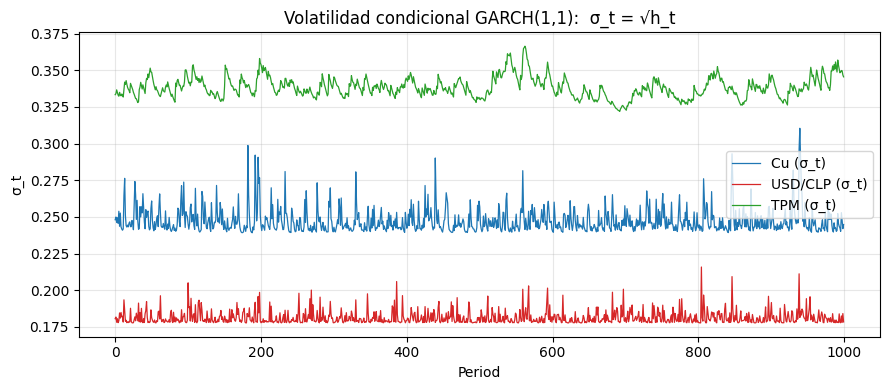

In [9]:
Zc = Causal_Link(Zbase, G)
plt.figure(figsize=(9, 4))
for i,(P,nm,c) in enumerate(zip([PCu,PUSD,PTPM],NAMES,["tab:blue","tab:red","tab:green"])):
    _, h = SimulateGARCH(T, *P, Zc[:, i])
    plt.plot(np.sqrt(h), label=f"{nm} (σ_t)", lw=0.9, color=c)
plt.title("Volatilidad condicional GARCH(1,1):  σ_t = √h_t")
plt.xlabel("Period"); plt.ylabel("σ_t"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 10. Cierre 📌
Este cuaderno reproduce fielmente la memoria de cálculo **Parte 1** en Python: el generador GARCH+CausalLink+ARIMA, sus pruebas de estacionariedad y correlación, y la ventana `xe` que alimenta la tokenización (Parte 2A). Junto con los cuadernos de la **Versión A** (diagnóstico T0.3) y **Versión B** ($R_G$), completa la trazabilidad del pipeline sintético de extremo a extremo.

> 🔌 Para datos reales: reemplazar `Generar_Sistema_Economico` por la carga de Cochilco (cobre) y BCCh (USD/CLP, TPM), 2003–2024 mensual.